# Speed Benchmark Comparison ESM3di vs ProstT5 vs ColabFold

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Runtime as a Function of Number of Sequences 

In [2]:
results_df = pd.read_csv("results/timing_results.csv")
results_df.head()

,model_name,dataset_name,num_sequences,total_residues,wall_time_seconds,sequences_per_second,residues_per_second,peak_vram_gb,device
0,colabfold,subset_10.fasta,10,2996,599.880226,0.016670,4.994330,0.000000,cuda
1,esm3di,subset_10.fasta,10,2996,0.414320,24.135916,7231.120288,2.394156,cuda
2,esm3di,subset_50.fasta,50,14812,1.463287,34.169638,10122.413467,2.394529,cuda
3,esm3di,subset_100.fasta,100,31045,2.856880,35.003225,10866.751247,3.015549,cuda
4,esm3di,subset_500.fasta,500,158266,13.709790,36.470288,11544.013323,3.073945,cuda


In [3]:
# function that plots time as a function of subset size for each model log log scale
def plot_time_vs_subset_size(results_df, model_names=["esm3di", "prostt5", "colabfold"]):
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")
    for model in model_names:
        subset_df = results_df[results_df["model_name"] == model]
        plt.plot(subset_df["num_sequences"], subset_df["wall_time_seconds"], marker="o", label=model)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Subset Size (log scale)")
    plt.ylabel("Time (seconds, log scale)")
    plt.title("Time vs Subset Size for Different Models")
    plt.legend()
    plt.tight_layout()
    plt.savefig("results/time_vs_subset_size.png")
    plt.show()

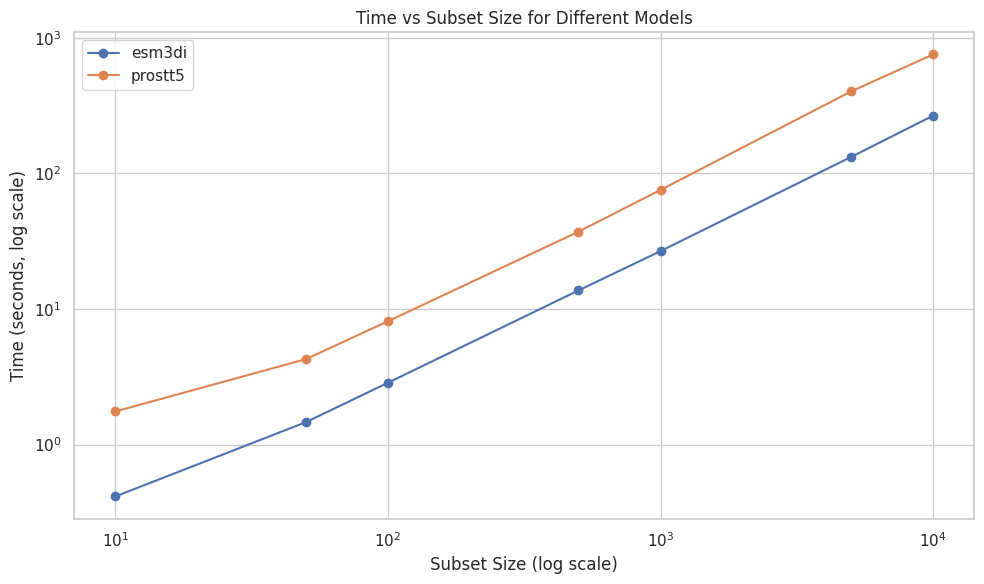

In [4]:
plot_time_vs_subset_size(results_df, model_names=["esm3di", "prostt5"])

## Runtime as a Function of Sequence Length

for each length we use n=32 seqeunces

In [16]:
seq_length_df = pd.read_csv("results/length_bins_results.csv")

seq_length_df['average_length'] = seq_length_df['total_residues'] / seq_length_df['num_sequences']
seq_length_df

,model_name,dataset_name,num_sequences,total_residues,wall_time_seconds,sequences_per_second,residues_per_second,peak_vram_gb,device,average_length
0,esm3di,bin_L100.fasta,32,3214,0.403648,79.277058,7962.389557,1.517306,cuda,100.43750
1,esm3di,bin_L200.fasta,32,6402,0.500334,63.957282,12795.453763,1.611275,cuda,200.06250
2,esm3di,bin_L300.fasta,32,9596,0.748485,42.753031,12820.565182,1.725227,cuda,299.87500
3,esm3di,bin_L400.fasta,32,12796,0.958862,33.372901,13344.988626,1.869110,cuda,399.87500
4,esm3di,bin_L500.fasta,32,15980,1.285951,24.884315,12426.604774,2.005730,cuda,499.37500
5,esm3di,bin_L600.fasta,32,19215,1.538846,20.794802,12486.628982,2.151372,cuda,600.46875
6,esm3di,bin_L700.fasta,32,22391,1.813205,17.648306,12348.850718,2.290532,cuda,699.71875
7,esm3di,bin_L800.fasta,32,25584,2.142239,14.937640,11942.643367,2.983340,cuda,799.50000
8,esm3di,bin_L900.fasta,32,28834,2.375662,13.469927,12137.246223,3.074859,cuda,901.06250
9,esm3di,bin_L1000.fasta,32,31975,2.628592,12.173819,12164.308689,3.172241,cuda,999.21875


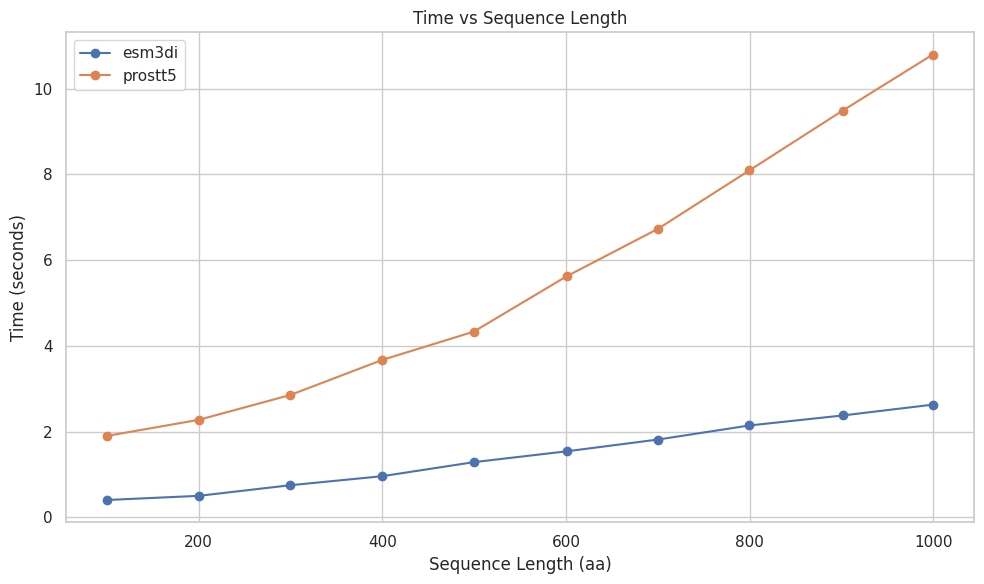

In [17]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
for model in ["esm3di", "prostt5"]:
    length_df = seq_length_df[seq_length_df["model_name"] == model]
    plt.plot(length_df["average_length"], length_df["wall_time_seconds"], marker="o", label=model)
plt.xlabel("Sequence Length (aa)")
plt.ylabel("Time (seconds)")
plt.title("Time vs Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()